<a href="https://colab.research.google.com/github/sofialuiza15/projetos-ml/blob/main/Foundation_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Foundation models

Esse notebook aplica o modelo da IBM Patch TST Mixer em 5 datasets diferentes.

In [ ]:
!pip install sktime

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import sklearn
import matplotlib.pyplot as plt
import copy

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sktime.datasets import load_forecastingdata

Começo escolhendo uma série temporal do dataset e fazendo o tratamento do dataset.

In [ ]:
def extract_series(data, idx=0):
    row = data.iloc[idx]
    y = pd.to_numeric(pd.Series(row["series_value"]), errors="coerce")
    y = y.interpolate().bfill().ffill()
    return y.astype("float32")

Converto a série para tensor e crio as janelas deslizantes.

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, series, seq_len, pred_len):
        values = torch.tensor(series.values, dtype=torch.float32)

        X, y = [], []
        for i in range(len(values) - seq_len - pred_len):
            X.append(values[i:i + seq_len])
            y.append(values[i + seq_len:i + seq_len + pred_len])

        self.X = torch.stack(X)
        self.y = torch.stack(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx].unsqueeze(0), self.y[idx]

Divisão da série em patches e compreensão de alguns padrões locais. Criação do pred_len (valores futuros).

In [ ]:
class PatchMixer(nn.Module):
    def __init__(self, seq_len, patch_len, pred_len, d_model=64):
        super().__init__()
        assert seq_len % patch_len == 0

        self.patch_len = patch_len
        self.n_patches = seq_len // patch_len

        self.patch_proj = nn.Linear(patch_len, d_model)

        self.feature_mixer = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU()
        )

        self.temporal_mixer = nn.Sequential(
            nn.Linear(self.n_patches, self.n_patches),
            nn.ReLU()
        )

        self.head = nn.Linear(d_model * self.n_patches, pred_len)

    def forward(self, x):
        patches = x.unfold(2, self.patch_len, self.patch_len)
        patches = self.patch_proj(patches)
        patches = self.feature_mixer(patches)

        patches = patches.transpose(-1, -2)
        patches = self.temporal_mixer(patches)
        patches = patches.transpose(-1, -2)

        return self.head(patches.reshape(x.size(0), -1))

Aqui ocorre o treinamento do modelo, defino a função de perda ```HuberLoss```. Garanto que o treinamento pare quando o modelo para de melhorar por 5 épocas seguidas.

In [ ]:
def train_with_early_stopping(
    model, train_loader, val_loader,
    epochs=30, lr=1e-3, patience=5
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.HuberLoss()

    best_val = float("inf")
    best_state = None
    no_improve = 0

    for epoch in range(epochs):
        model.train()
        for X, y in train_loader:
            optimizer.zero_grad()
            loss = loss_fn(model(X), y)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y in val_loader:
                val_loss += loss_fn(model(X), y).item()

        val_loss /= len(val_loader)
        print(f"Epoch {epoch+1} | Val Loss = {val_loss:.5f}")

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model

A avaliação é feita usando a ```MAE``` na escala real do dataset.

In [ ]:
def evaluate(model, loader, scaler):
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for X, y in loader:
            preds.append(model(X))
            trues.append(y)

    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()

    preds = scaler.inverse_transform(preds.reshape(-1, 1)).ravel()
    trues = scaler.inverse_transform(trues.reshape(-1, 1)).ravel()

    mae = np.mean(np.abs(preds - trues))

    return mae

Essa é a função principal, que chama todas as outras funções que foram definidas anteriomente.
Ela carrega o dataset, extrai a série e normaliza os valores. Faz a divisão de treino e teste, treina o modelo e avalia.

In [ ]:
def result(dataset_name, seq_len=70, pred_len=7, patch_len=7):
    print(f"\nDATASET: {dataset_name}")

    data, _ = load_forecastingdata(name=dataset_name)
    y_raw = extract_series(data)
    y_raw = y_raw.interpolate()

    n = len(y_raw)
    train_end = int(0.7 * n)
    val_end   = int(0.8 * n)

    y_train_raw = y_raw[:train_end]
    y_val_raw   = y_raw[train_end - seq_len:]
    y_test_raw  = y_raw[val_end - seq_len:]

    scaler = StandardScaler()
    y_train_scaled = scaler.fit_transform(
        y_train_raw.values.reshape(-1, 1)
    ).flatten()

    y_val_scaled = scaler.transform(
        y_val_raw.values.reshape(-1, 1)
    ).flatten()

    y_test_scaled = scaler.transform(
        y_test_raw.values.reshape(-1, 1)
    ).flatten()

    train_dataset = TimeSeriesDataset(
        pd.Series(y_train_scaled), seq_len, pred_len
    )
    val_dataset = TimeSeriesDataset(
        pd.Series(y_val_scaled), seq_len, pred_len
    )
    test_dataset = TimeSeriesDataset(
        pd.Series(y_test_scaled), seq_len, pred_len
    )

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
    val_loader   = DataLoader(val_dataset, batch_size=32)
    test_loader  = DataLoader(test_dataset, batch_size=32)

    model = PatchMixer(seq_len, patch_len, pred_len)
    model = train_with_early_stopping(model, train_loader, val_loader)

    mae = evaluate(model, test_loader, scaler)
    mae_rel = (mae / y_raw.mean()) * 100
    print(f"PatchTST MAE (raw): {mae:.2f}")
    print(f"PatchTST MAE (rel): {mae_rel:.2f}%")

    return model, scaler, y_raw

In [ ]:
def seasonal_naive_result(y_raw, pred_len=7, sp=7):
    y = y_raw.values
    y_train = y[:-pred_len]
    y_test  = y[-pred_len:]

    season = y_train[-sp:]
    y_pred = np.tile(season, int(np.ceil(pred_len / sp)))[:pred_len]

    mae = np.mean(np.abs(y_test - y_pred))
    print(f"Seasonal Naive MAE (raw): {mae:.2f}")

    return y_pred

In [ ]:
def plot_full_series(series, title="Time Series"):

    plt.figure(figsize=(14, 5))
    plt.plot(series.values, linewidth=1)
    plt.title(title)
    plt.xlabel("Tempo")
    plt.ylabel("Valor")
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
def plot_prediction_evolution(series, model, naive_pred, seq_len, pred_len, scaler):
    window = series.values[-(seq_len + pred_len):]
    past = window[:seq_len]
    real = window[seq_len:]

    x = scaler.transform(past.reshape(-1, 1))
    x_tensor = torch.tensor(x, dtype=torch.float32).view(1, 1, seq_len)

    with torch.no_grad():
        patch_pred = model(x_tensor).squeeze().numpy()

    patch_pred = scaler.inverse_transform(patch_pred.reshape(-1, 1)).ravel()

    t_past = range(seq_len)
    t_future = range(seq_len, seq_len + pred_len)

    plt.figure(figsize=(12, 6))
    plt.plot(t_past, past, label="Contexto", color="gray")
    plt.plot(t_future, real, label="Real", marker="o")
    plt.plot(t_future, patch_pred, label="PatchTST", linestyle="--")
    plt.plot(t_future, naive_pred, label="Seasonal Naive", linestyle=":")
    plt.axvline(seq_len - 1, color="black", linestyle=":")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


DATASET: us_births_dataset
Epoch 1 | Val Loss = 0.09967
Epoch 2 | Val Loss = 0.08365
Epoch 3 | Val Loss = 0.07691
Epoch 4 | Val Loss = 0.07426
Epoch 5 | Val Loss = 0.07362
Epoch 6 | Val Loss = 0.07327
Epoch 7 | Val Loss = 0.07229
Epoch 8 | Val Loss = 0.07142
Epoch 9 | Val Loss = 0.07080
Epoch 10 | Val Loss = 0.07025
Epoch 11 | Val Loss = 0.06953
Epoch 12 | Val Loss = 0.06864
Epoch 13 | Val Loss = 0.06758
Epoch 14 | Val Loss = 0.06664
Epoch 15 | Val Loss = 0.06604
Epoch 16 | Val Loss = 0.06553
Epoch 17 | Val Loss = 0.06524
Epoch 18 | Val Loss = 0.06486
Epoch 19 | Val Loss = 0.06472
Epoch 20 | Val Loss = 0.06473
Epoch 21 | Val Loss = 0.06473
Epoch 22 | Val Loss = 0.06474
Epoch 23 | Val Loss = 0.06471
Epoch 24 | Val Loss = 0.06495
Epoch 25 | Val Loss = 0.06526
Epoch 26 | Val Loss = 0.06542
Epoch 27 | Val Loss = 0.06602
Epoch 28 | Val Loss = 0.06651
PatchTST MAE (raw): 259.36
PatchTST MAE (rel): 2.69%
Seasonal Naive MAE (raw): 1245.00


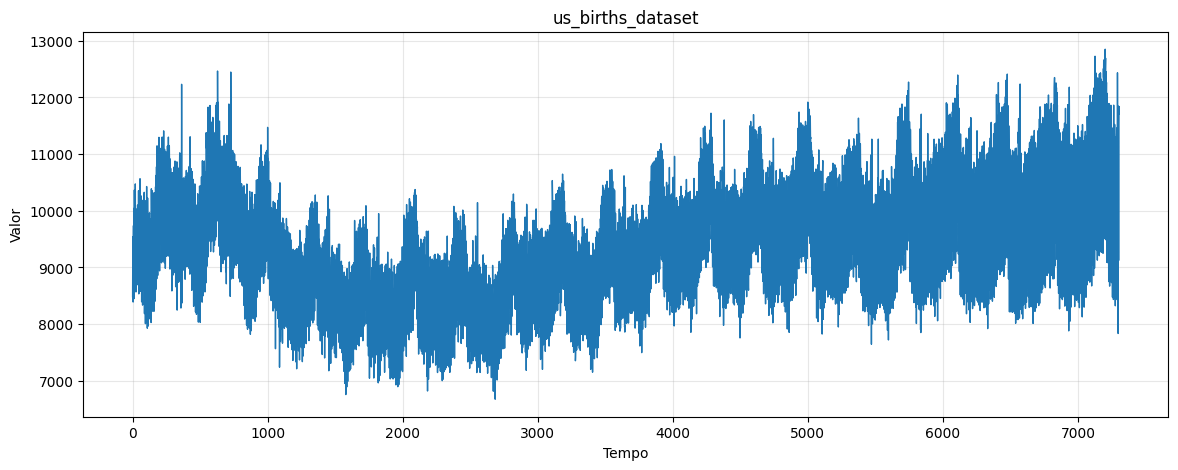

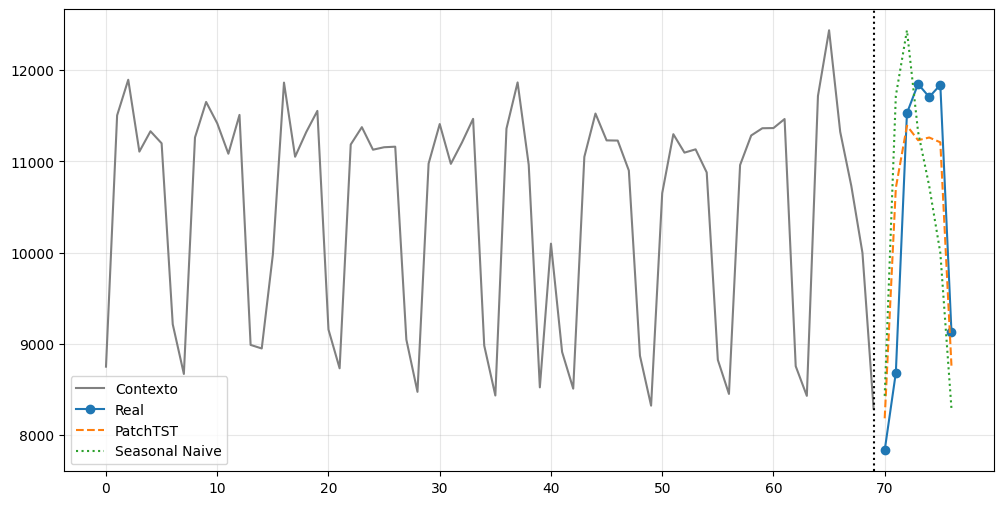

In [ ]:
model, scaler, y_raw = result("us_births_dataset")

naive_pred = seasonal_naive_result(
    y_raw=y_raw,
    pred_len=7,
    sp=7
)

plot_full_series(y_raw, "us_births_dataset")

plot_prediction_evolution(
    series=y_raw,
    model=model,
    naive_pred=naive_pred,
    seq_len=70,
    pred_len=7,
    scaler=scaler
)


DATASET: weather_dataset
Epoch 1 | Val Loss = 0.17628
Epoch 2 | Val Loss = 0.17628
Epoch 3 | Val Loss = 0.17643
Epoch 4 | Val Loss = 0.17651
Epoch 5 | Val Loss = 0.17668
Epoch 6 | Val Loss = 0.17690
Epoch 7 | Val Loss = 0.17712
PatchTST MAE (raw): 1.81
PatchTST MAE (rel): 109.59%
Seasonal Naive MAE (raw): 0.37


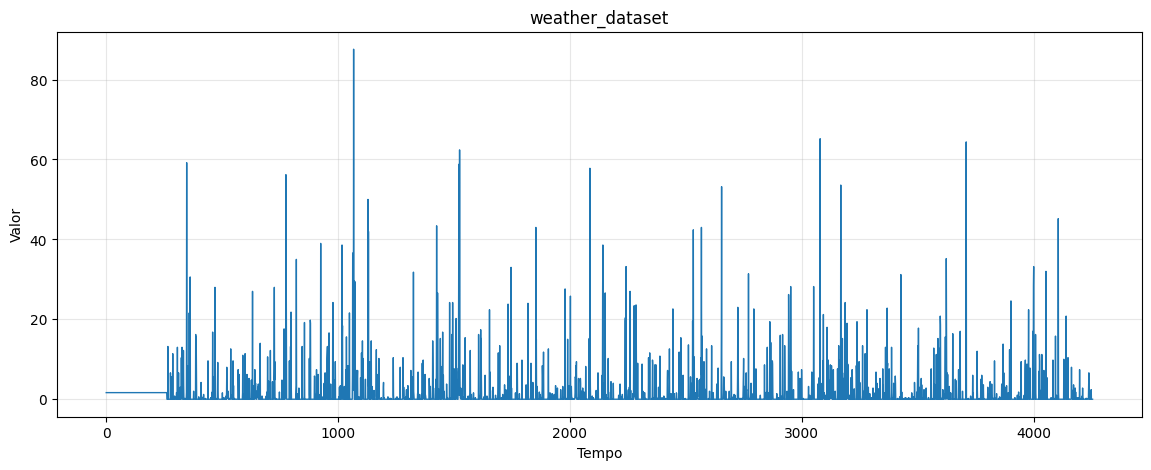

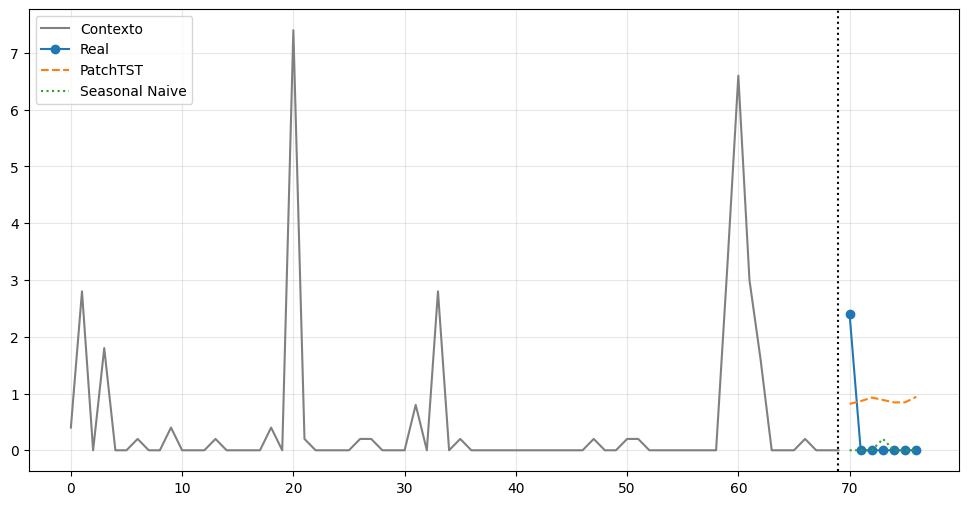

In [ ]:
model, scaler, y_raw = result("weather_dataset")

naive_pred = seasonal_naive_result(
    y_raw=y_raw,
    pred_len=7,
    sp=7
)

plot_full_series(y_raw, "weather_dataset")

plot_prediction_evolution(
    series=y_raw,
    model=model,
    naive_pred=naive_pred,
    seq_len=70,
    pred_len=7,
    scaler=scaler
)



DATASET: nn5_daily_dataset_with_missing_values
Epoch 1 | Val Loss = 0.68624
Epoch 2 | Val Loss = 0.50027
Epoch 3 | Val Loss = 0.41174
Epoch 4 | Val Loss = 0.29734
Epoch 5 | Val Loss = 0.29415
Epoch 6 | Val Loss = 0.28886
Epoch 7 | Val Loss = 0.28362
Epoch 8 | Val Loss = 0.28703
Epoch 9 | Val Loss = 0.28665
Epoch 10 | Val Loss = 0.28323
Epoch 11 | Val Loss = 0.28499
Epoch 12 | Val Loss = 0.28525
Epoch 13 | Val Loss = 0.28327
Epoch 14 | Val Loss = 0.28510
Epoch 15 | Val Loss = 0.28659
PatchTST MAE (raw): 6.32
PatchTST MAE (rel): 21.99%
Seasonal Naive MAE (raw): 2.79


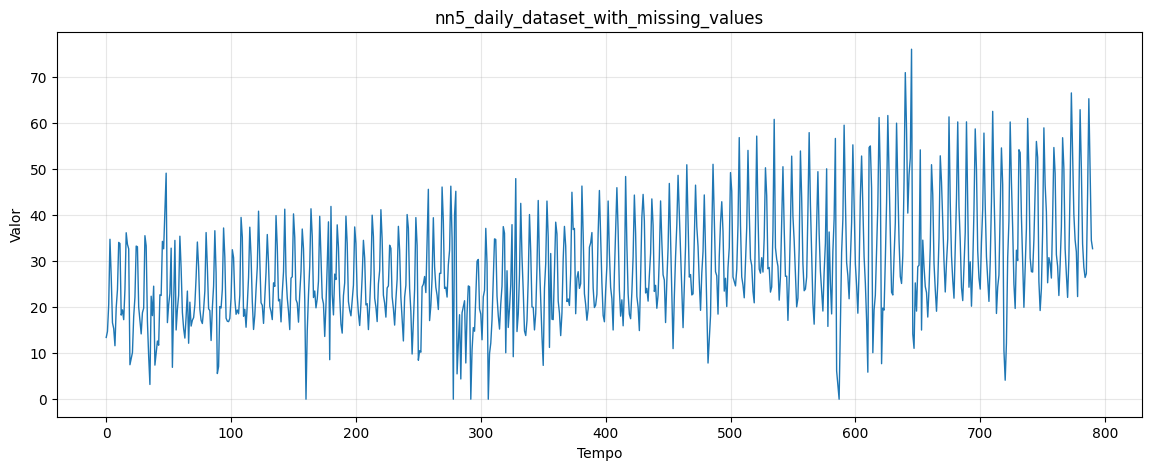

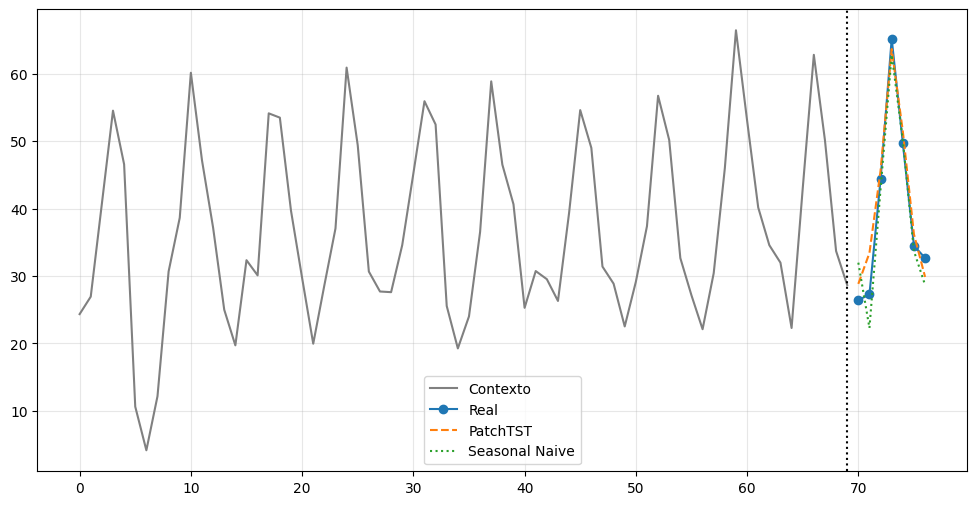

In [ ]:
model, scaler, y_raw = result("nn5_daily_dataset_with_missing_values")

naive_pred = seasonal_naive_result(
    y_raw=y_raw,
    pred_len=7,
    sp=7
)

plot_full_series(y_raw, "nn5_daily_dataset_with_missing_values")

plot_prediction_evolution(
    series=y_raw,
    model=model,
    naive_pred=naive_pred,
    seq_len=70,
    pred_len=7,
    scaler=scaler
)



DATASET: nn5_daily_dataset_without_missing_values
Epoch 1 | Val Loss = 0.79441
Epoch 2 | Val Loss = 0.51883
Epoch 3 | Val Loss = 0.47894
Epoch 4 | Val Loss = 0.33696
Epoch 5 | Val Loss = 0.29643
Epoch 6 | Val Loss = 0.30136
Epoch 7 | Val Loss = 0.29291
Epoch 8 | Val Loss = 0.29599
Epoch 9 | Val Loss = 0.30139
Epoch 10 | Val Loss = 0.29908
Epoch 11 | Val Loss = 0.30135
Epoch 12 | Val Loss = 0.30516
PatchTST MAE (raw): 6.45
PatchTST MAE (rel): 22.59%
Seasonal Naive MAE (raw): 2.79


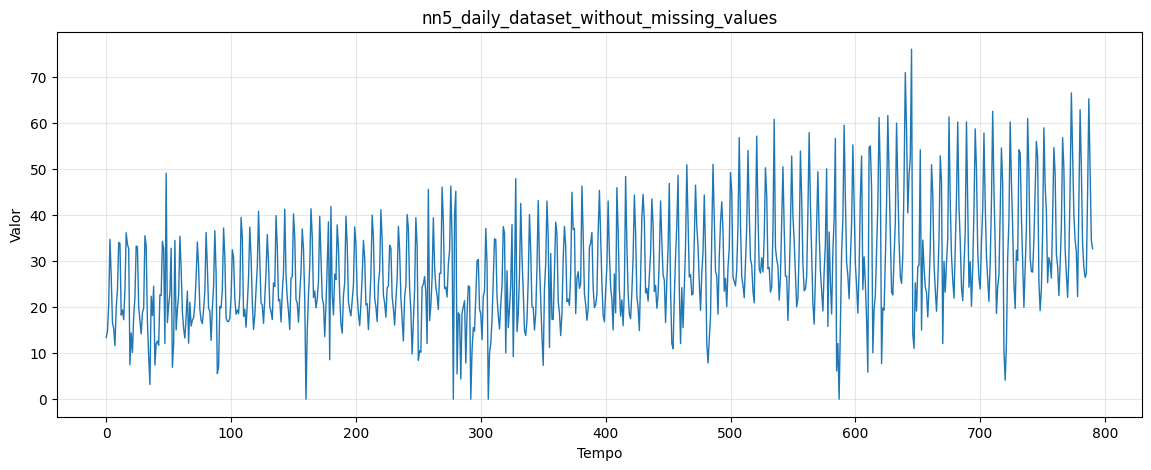

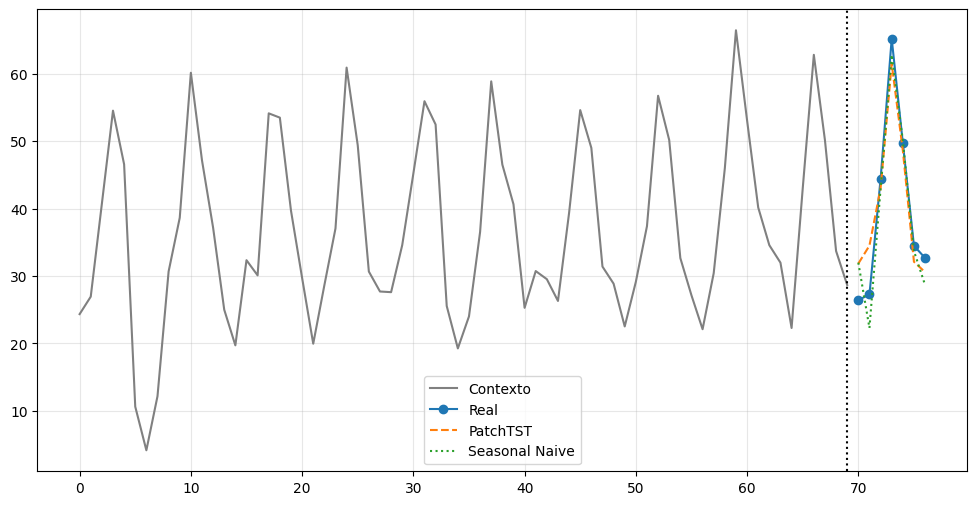

In [ ]:
model, scaler, y_raw = result("nn5_daily_dataset_without_missing_values")

naive_pred = seasonal_naive_result(
    y_raw=y_raw,
    pred_len=7,
    sp=7
)

plot_full_series(y_raw, "nn5_daily_dataset_without_missing_values")

plot_prediction_evolution(
    series=y_raw,
    model=model,
    naive_pred=naive_pred,
    seq_len=70,
    pred_len=7,
    scaler=scaler
)



DATASET: m4_daily_dataset
Epoch 1 | Val Loss = 2.62484
Epoch 2 | Val Loss = 1.92227
Epoch 3 | Val Loss = 0.52563
Epoch 4 | Val Loss = 0.22312
Epoch 5 | Val Loss = 0.60888
Epoch 6 | Val Loss = 0.18336
Epoch 7 | Val Loss = 0.40884
Epoch 8 | Val Loss = 0.17920
Epoch 9 | Val Loss = 0.28965
Epoch 10 | Val Loss = 0.16077
Epoch 11 | Val Loss = 0.21928
Epoch 12 | Val Loss = 0.14687
Epoch 13 | Val Loss = 0.19688
Epoch 14 | Val Loss = 0.14585
Epoch 15 | Val Loss = 0.23080
Epoch 16 | Val Loss = 0.15543
Epoch 17 | Val Loss = 0.38881
Epoch 18 | Val Loss = 0.14997
Epoch 19 | Val Loss = 0.52235
PatchTST MAE (raw): 106.97
PatchTST MAE (rel): 7.48%
Seasonal Naive MAE (raw): 16.37


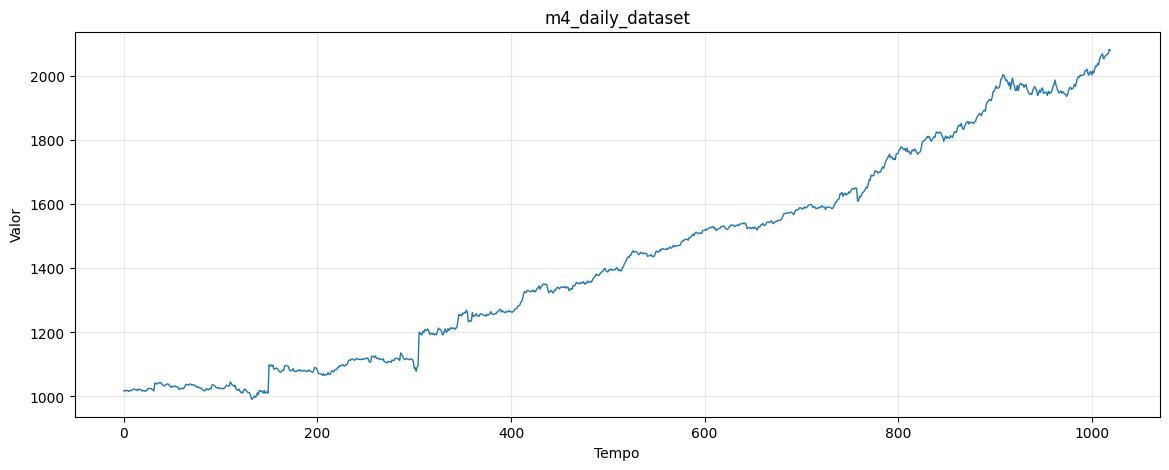

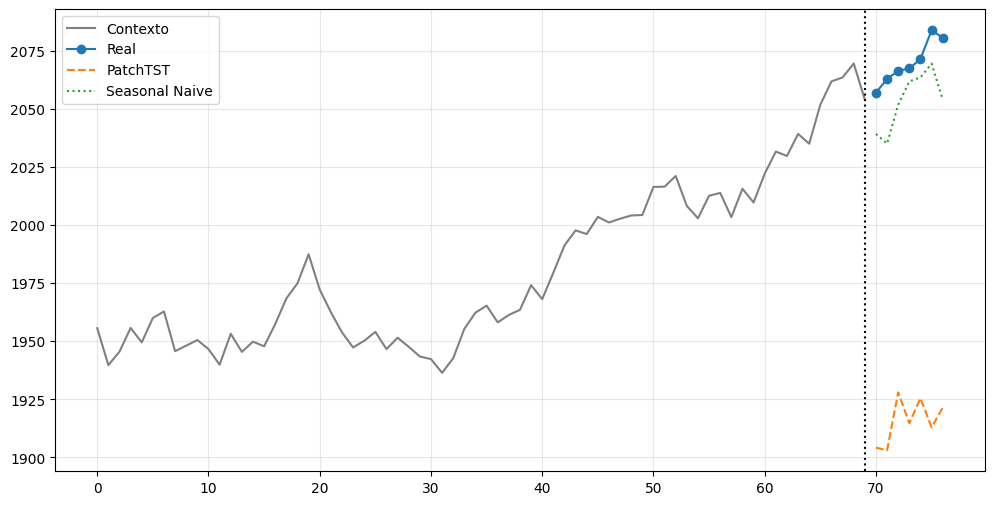

In [ ]:
model, scaler, y_raw = result("m4_daily_dataset")

naive_pred = seasonal_naive_result(
    y_raw=y_raw,
    pred_len=7,
    sp=7
)

plot_full_series(y_raw, "m4_daily_dataset")

plot_prediction_evolution(
    series=y_raw,
    model=model,
    naive_pred=naive_pred,
    seq_len=70,
    pred_len=7,
    scaler=scaler
)